In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

dir_name = '/home/guerrini/sp_validation/cosmo_val'
if dir_name not in sys.path:
    sys.path.append(dir_name)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import scale as mscale
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.cosmology import Planck18
import healpy as hp
import camb
from cosmology import Cosmology
from cosmo_val import CosmologyValidation
import pyccl as ccl
import fitsio
from scipy.interpolate import interp1d

import seaborn as sns

from sp_validation.utils_cosmo_val import SquareRootScale

mscale.register_scale(SquareRootScale)

sns.color_palette("husl")

%matplotlib inline

In [2]:
cl = np.load("/n09data/guerrini/glass_mock_v1.4.6_rerun/results/cl_glass_mock_00030_4096.npy")

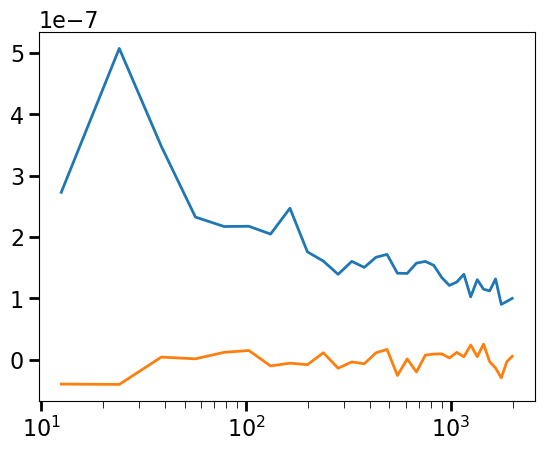

In [3]:
plt.figure()

plt.plot(cl[0], cl[0]*cl[1])
plt.plot(cl[0], cl[0]*cl[4])
plt.xscale('log')

plt.show()

In [4]:
root_dir_glass_mock = '/n09data/guerrini/glass_mock_v1.4.6_rerun/results/'
root_dir_target_cat = '/n17data/UNIONS/WL/v1.4.x/v1.4.6/'
n_sim = 1
index_sim = str(n_sim).zfill(5)
glass_mock = f'unions_glass_sim_{index_sim}_4096.fits'
target_mock = 'unions_shapepipe_cut_struc_2024_v1.4.6.fits'

root_dirs = [root_dir_glass_mock, root_dir_target_cat]
cats = [glass_mock, target_mock]
labels = ['glass_mock', 'target_mock']
w_cols = ['w', 'w_des'] 

In [5]:
#Create n_gal maps
for root_dir, cat, label, w_col in zip(root_dirs, cats, labels, w_cols):
    data = fits.getdata(root_dir + cat)

    if label == 'glass_mock':
        n_gal = np.zeros(hp.nside2npix(4096))
        
        ra = data['ra']
        dec = data['dec']
        pix = hp.ang2pix(4096, np.radians(90 - dec), np.radians(ra))

        unique_pix, idx, idx_rep = np.unique(pix, return_index=True, return_inverse=True)
        n_gal[unique_pix] = np.bincount(idx_rep)
        mask = n_gal != 0

        area = np.sum(mask) * hp.nside2pixarea(4096, degrees=True)
        del n_gal, mask

    if label == 'target_mock':
        area = 2400
    print(f"Area of {label} = {area} deg^2")
        

    #Compute effective number of galaxies
    e1 = data['e1']
    e2 = data['e2']
    
    
    n_eff_gal = 1/(area*60*60)*(np.sum(data[w_col]))**2/np.sum(data[w_col]**2)
    print(f"n_eff_gal of {label} = {n_eff_gal} arcmin^-2")

    #Compute shape noise
    sigma_e = np.sqrt(
    0.5*(np.sum((data['e1']*data[w_col])**2) + np.sum((data['e2']*data[w_col])**2)) / np.sum(data[w_col]**2)
    )
    print(f"sigma_e of {label} = {sigma_e}")

Area of glass_mock = 2709.086002579646 deg^2
n_eff_gal of glass_mock = 6.19845749764113 arcmin^-2
sigma_e of glass_mock = 0.26822442943277625
Area of target_mock = 2400 deg^2
n_eff_gal of target_mock = 6.141962124965772 arcmin^-2
sigma_e of target_mock = 0.26840896706663514


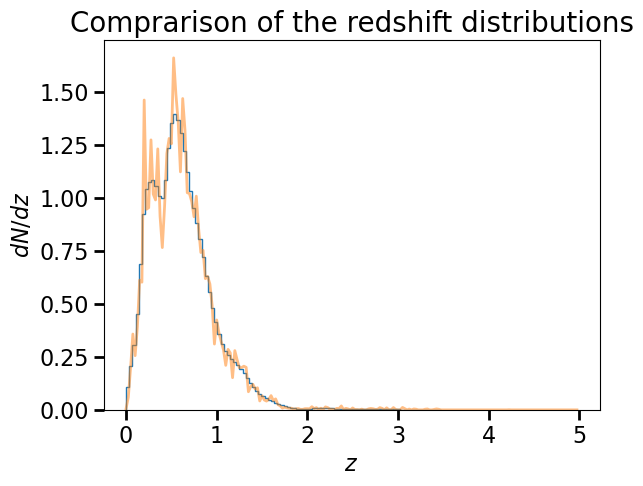

In [6]:
#Check the redshift distribution
glass_cat = fits.getdata(root_dir_glass_mock + glass_mock)

plt.figure()

plt.hist(glass_cat['PHOTO_Z'], bins=100, histtype='step', label='glass_mock', density=True)

redshift_distr = np.loadtxt('/n17data/sguerrini/UNIONS/WL/nz/v1.4.6/nz_SP_v1.4.6_A.txt')
z, dndz = redshift_distr[:, 0], redshift_distr[:, 1]

plt.plot(z, dndz, label='SP_A', alpha=0.5)

plt.xlabel(r'$z$')
plt.ylabel(r'$dN/dz$')
plt.title('Comprarison of the redshift distributions')

plt.show()


In [7]:
#Compute theory Cl'set
planck18 = Planck18
h = planck18.H0.value/100
Om = planck18.Om0
Ob = planck18.Ob0
Oc = Om - Ob
ns = 0.965
As = 2.1e-9

pars = camb.set_params(H0=100*h, omch2=Oc*h**2, ombh2=Ob*h**2, ns=ns, As=As,
                                    NonLinear=camb.model.NonLinear_both, WantTransfer=True)

nside = 1024
lmax = 2*nside

#getthe expected cl's from CAMB
pars.min_l = 1
pars.set_for_lmax(lmax)
pars.SourceWindows = [
    camb.sources.SplinedSourceWindow(z=z, W=dndz, source_type='lensing')
]
theory_cls = camb.get_results(pars).get_source_cls_dict(lmax=lmax, raw_cl=True)


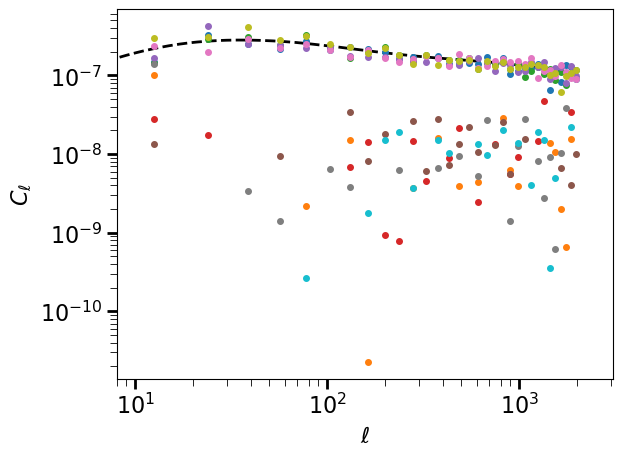

In [9]:
l = np.arange(lmax+1)
pw = hp.pixwin(nside, lmax=lmax)

plt.figure()

for n_sim in range(1, 6):
    index_sim = str(n_sim).zfill(5)
    pseudo_cl_glass = np.load(f"{root_dir_glass_mock}/cl_glass_mock_{index_sim}_4096.npy")

    ell_eff = pseudo_cl_glass[0]



    plt.errorbar(ell_eff, ell_eff*pseudo_cl_glass[1], fmt='o', capsize=2, markersize=4, label='EE')
    plt.errorbar(ell_eff, ell_eff*pseudo_cl_glass[4], fmt='o', capsize=2, markersize=4, label='BB')
plt.plot(l, l*theory_cls['W1xW1'], label=r'$C_\ell$ theory', c='k', ls='--')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')


plt.xscale('log')
plt.yscale('log')

plt.xlim(8, 3*nside-1)

plt.show()

In [10]:
#Get theory correlation function from CCL
#Define the cosmology
theta_arcmin = np.logspace(np.log10(0.1), np.log10(250), 1000)
h = planck18.H0.value/100
Oc = planck18.Om0 - planck18.Ob0
Ob = planck18.Ob0
sigma8 = float(camb.get_results(pars).get_sigma8())
n_s = 0.965
cosmo = ccl.Cosmology(
    h=h,
    Omega_c = Oc,
    Omega_b = Ob,
    sigma8 = sigma8,
    n_s = n_s,
    transfer_function='boltzmann_camb',
)

#Define the redshift distribution
z, dndz = np.loadtxt('/n17data/sguerrini/UNIONS/WL/nz/v1.4.6/nz_SP_v1.4.6_A.txt', unpack=True)

tracer = ccl.WeakLensingTracer(cosmo, dndz=(z, dndz), ia_bias=None)

#COmpute the angular power spectrum C_ell
ell = np.logspace(0, np.log10(10000), 2000)
cl_gg = ccl.angular_cl(cosmo, tracer, tracer, ell)

#Compute the 2PCF
theta_deg = theta_arcmin / 60
#xi+ fit
xi_p_theta = ccl.correlation(cosmo, ell=ell, C_ell=cl_gg, theta=theta_deg, type='GG+')
#xi- fit
xi_m_theta = ccl.correlation(cosmo, ell=ell, C_ell=cl_gg, theta=theta_deg, type='GG-')

/tmp/ipykernel_233967/1579801276.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sigma8 = float(camb.get_results(pars).get_sigma8())


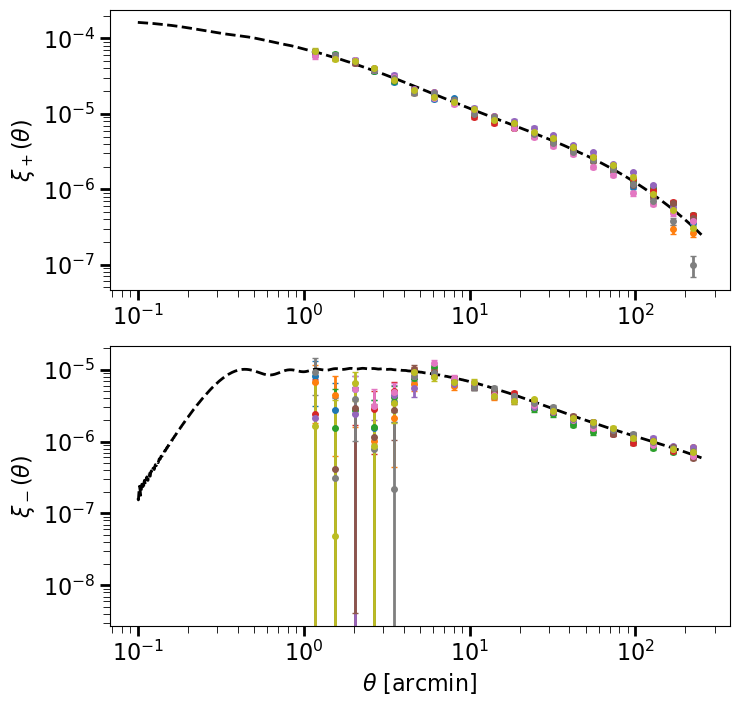

In [12]:
import treecorr 

n_sim = 1
index_sim = str(n_sim).zfill(5)

theta_min = 1.0
theta_max = 250.0
nbins = 20
var_method = 'jackknife'

treecorr_config = {
            "ra_units": "degrees",
            "dec_units": "degrees",
            "min_sep": theta_min,
            "max_sep": theta_max,
            "sep_units": "arcmin",
            "nbins": nbins,
            "var_method": var_method,
        }

gg = treecorr.GGCorrelation(treecorr_config)

#Load the measurement
gg.read(f'{root_dir_glass_mock}/xi_glass_mock_{index_sim}_4096_nbins=20.fits')


plt.figure(figsize=(8, 8))

plt.subplot(211)

for i in range(1, 10):
    index_sim = str(i).zfill(5)
    gg.read(f'{root_dir_glass_mock}/xi_glass_mock_{index_sim}_4096_nbins=20.fits')

    plt.errorbar(gg.meanr, gg.xip, yerr=np.sqrt(gg.varxip), fmt='o', label=r'$\xi_+$ data', capsize=2, markersize=4)
plt.plot(theta_arcmin, xi_p_theta, label=r'$\xi_+$ theory', linestyle='--', color='black')

plt.yscale('log')
plt.xscale('log')

plt.ylabel(r'$\xi_+(\theta)$')

plt.subplot(212)

for i in range(1, 10):
    index_sim = str(i).zfill(5)
    gg.read(f'{root_dir_glass_mock}/xi_glass_mock_{index_sim}_4096_nbins=20.fits')

    plt.errorbar(gg.meanr, gg.xim, yerr=np.sqrt(gg.varxim), fmt='o', label=r'$\xi_-$ data', capsize=2, markersize=4)
plt.plot(theta_arcmin, xi_m_theta, label=r'$\xi_-$ theory', linestyle='--', color='black')

plt.yscale('log')
plt.xscale('log')

plt.ylabel(r'$\xi_-(\theta)$')
plt.xlabel(r'$\theta$ [arcmin]')

plt.savefig('validate_mock.png')
plt.show()

In [13]:
### Plot against data
cosmo_val_output = "/home/guerrini/sp_validation/cosmo_val/output/"
ell = fits.open(cosmo_val_output + "pseudo_cl_SP_v1.4.6_leak_corr.fits")["PSEUDO_CELL"].data["ELL"]
cl_data = fits.open(cosmo_val_output + "pseudo_cl_SP_v1.4.6_leak_corr.fits")["PSEUDO_CELL"].data["EE"]
cl_cov = fits.open(cosmo_val_output + "pseudo_cl_cov_g_ng_iNKA_SP_v1.4.6_leak_corr.fits")["COVAR_FULL"].data
gg.read(f'{cosmo_val_output}/SP_v1.4.6_leak_corr_xi_minsep=1.0_maxsep=250.0_nbins=20_npatch=1.txt')

# Shift the nz
redshift_shift = 0.033
z_shift = z + redshift_shift
f = interp1d(z, dndz, kind='cubic', fill_value=0.0, bounds_error=False)
dndz_shift = f(z_shift)
dndz_shift /= np.trapz(dndz_shift, z_shift)

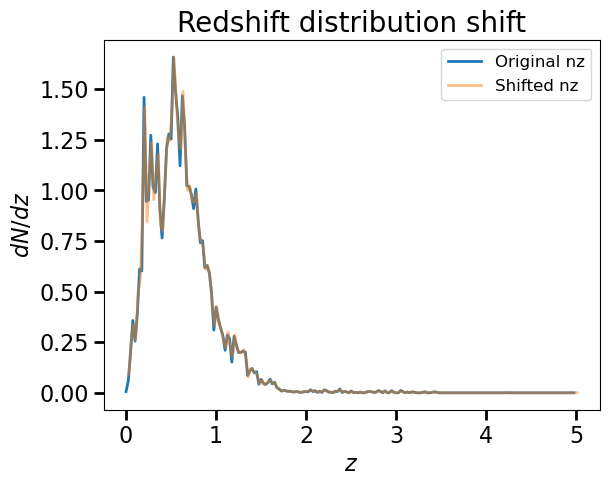

In [15]:
plt.figure()

plt.plot(z, dndz, label='Original nz')
plt.plot(z_shift, dndz_shift, alpha=0.5, label='Shifted nz')
plt.xlabel(r'$z$')
plt.ylabel(r'$dN/dz$')
plt.title('Redshift distribution shift')
plt.legend()
plt.show()

In [16]:
# Compute theory for the shifted Cells
pars.SourceWindows = [
    camb.sources.SplinedSourceWindow(z=z_shift, W=dndz_shift, source_type='lensing')
]
theory_cls_shift = camb.get_results(pars).get_source_cls_dict(lmax=lmax, raw_cl=True)

tracer = ccl.WeakLensingTracer(cosmo, dndz=(z, dndz), ia_bias=None)

#COmpute the angular power spectrum C_ell
ell_ccl = np.logspace(0, np.log10(10000), 2000)
cl_gg = ccl.angular_cl(cosmo, tracer, tracer, ell_ccl)

#Compute the 2PCF
theta_deg = theta_arcmin / 60
#xi+ fit
xi_p_theta = ccl.correlation(cosmo, ell=ell_ccl, C_ell=cl_gg, theta=theta_deg, type='GG+')
#xi- fit
xi_m_theta = ccl.correlation(cosmo, ell=ell_ccl, C_ell=cl_gg, theta=theta_deg, type='GG-')


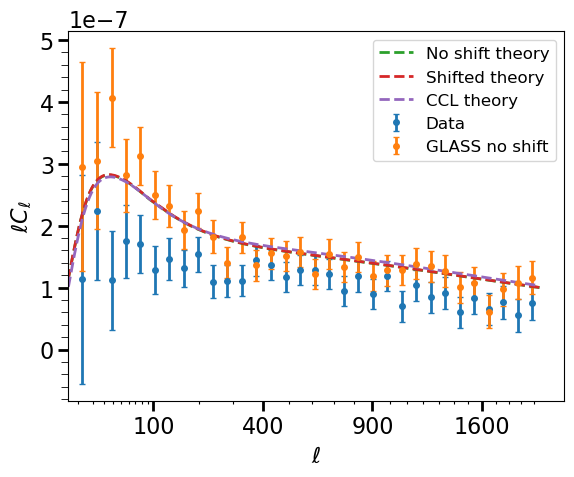

In [17]:
### Plot no shift prediction against data
plt.figure()

plt.errorbar(ell, ell*cl_data, yerr=ell*np.sqrt(np.diag(cl_cov)), fmt='o', capsize=2, markersize=4, label='Data')
plt.errorbar(ell_eff, ell_eff*pseudo_cl_glass[1], yerr=ell*np.sqrt(np.diag(cl_cov)), fmt='o', capsize=2, markersize=4, label='GLASS no shift')
plt.plot(l, l*theory_cls['W1xW1'], label='No shift theory', linestyle='--')
plt.plot(l, l*theory_cls_shift['W1xW1'], label='Shifted theory', linestyle='--')
plt.plot(ell_ccl[ell_ccl<=lmax], ell_ccl[ell_ccl<=lmax]*cl_gg[ell_ccl<=lmax], label='CCL theory', linestyle='--')

plt.xscale('squareroot')
plt.xticks(np.array([100, 400, 900, 1600]))
plt.minorticks_on()
plt.tick_params(axis='x', which='minor', length=2, width=0.8)
minor_ticks = [i*10 for i in range(1, 10)] + [i*100 for i in range(1, 21)]
plt.xticks(minor_ticks, minor=True)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell C_\ell$')

plt.legend()


plt.show()

In [18]:
# Plot adding ia bias
ia_bias = (z, np.ones_like(z)*0.83)
tracer = ccl.WeakLensingTracer(cosmo, dndz=(z, dndz), ia_bias=ia_bias)

#COmpute the angular power spectrum C_ell
ell_ccl = np.logspace(0, np.log10(10000), 2000)
cl_gg = ccl.angular_cl(cosmo, tracer, tracer, ell_ccl)

#Compute the 2PCF
theta_deg = theta_arcmin / 60
#xi+ fit
xi_p_theta = ccl.correlation(cosmo, ell=ell_ccl, C_ell=cl_gg, theta=theta_deg, type='GG+')
#xi- fit
xi_m_theta = ccl.correlation(cosmo, ell=ell_ccl, C_ell=cl_gg, theta=theta_deg, type='GG-')

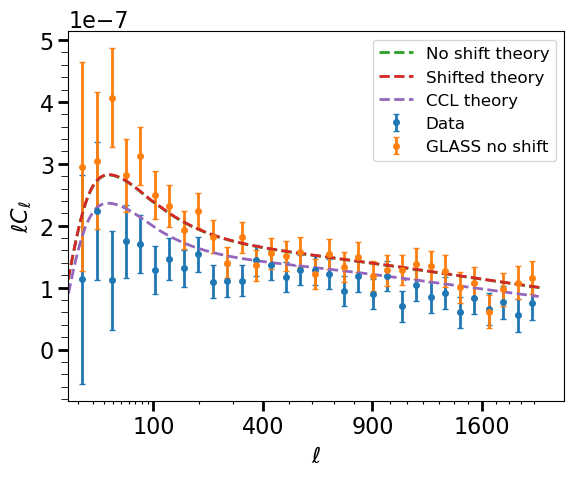

In [19]:
### Plot no shift prediction against data
plt.figure()

plt.errorbar(ell, ell*cl_data, yerr=ell*np.sqrt(np.diag(cl_cov)), fmt='o', capsize=2, markersize=4, label='Data')
plt.errorbar(ell_eff, ell_eff*pseudo_cl_glass[1], yerr=ell*np.sqrt(np.diag(cl_cov)), fmt='o', capsize=2, markersize=4, label='GLASS no shift')
plt.plot(l, l*theory_cls['W1xW1'], label='No shift theory', linestyle='--')
plt.plot(l, l*theory_cls_shift['W1xW1'], label='Shifted theory', linestyle='--')
plt.plot(ell_ccl[ell_ccl<=lmax], ell_ccl[ell_ccl<=lmax]*cl_gg[ell_ccl<=lmax], label='CCL theory', linestyle='--')

plt.xscale('squareroot')
plt.xticks(np.array([100, 400, 900, 1600]))
plt.minorticks_on()
plt.tick_params(axis='x', which='minor', length=2, width=0.8)
minor_ticks = [i*10 for i in range(1, 10)] + [i*100 for i in range(1, 21)]
plt.xticks(minor_ticks, minor=True)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell C_\ell$')

plt.legend()


plt.show()

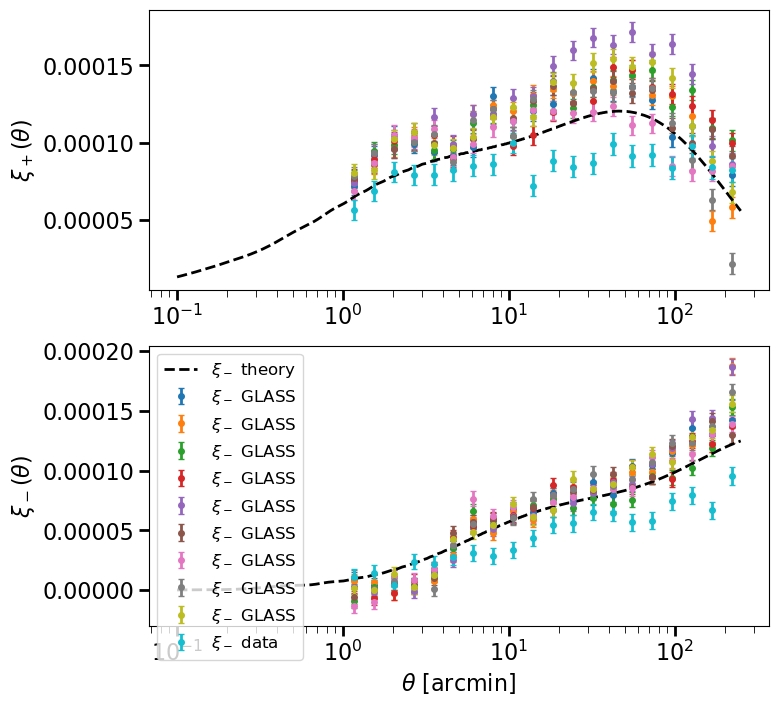

In [20]:
import treecorr 

n_sim = 30
index_sim = str(n_sim).zfill(5)

theta_min = 1.0
theta_max = 250.0
nbins = 20
var_method = 'jackknife'

treecorr_config = {
            "ra_units": "degrees",
            "dec_units": "degrees",
            "min_sep": theta_min,
            "max_sep": theta_max,
            "sep_units": "arcmin",
            "nbins": nbins,
            "var_method": var_method,
        }

gg_glass = treecorr.GGCorrelation(treecorr_config)

#Load the measurement
gg_glass.read(f'{root_dir_glass_mock}/xi_glass_mock_{index_sim}_4096_nbins=20.fits')


plt.figure(figsize=(8, 8))

plt.subplot(211)

for i in range(1, 10):
    index_sim = str(i).zfill(5)
    gg_glass.read(f'{root_dir_glass_mock}/xi_glass_mock_{index_sim}_4096_nbins=20.fits')

    plt.errorbar(gg_glass.meanr, gg_glass.meanr*gg_glass.xip, yerr=gg_glass.meanr*np.sqrt(gg_glass.varxip), fmt='o', label=r'$\xi_+$ GLASS', capsize=2, markersize=4)
plt.errorbar(gg.meanr, gg.meanr*gg.xip, yerr=gg.meanr*np.sqrt(gg.varxip), fmt='o', label=r'$\xi_+$ data', capsize=2, markersize=4)
plt.plot(theta_arcmin, theta_arcmin*xi_p_theta, label=r'$\xi_+$ theory', linestyle='--', color='black')


plt.xscale('log')

plt.ylabel(r'$\xi_+(\theta)$')

plt.subplot(212)

for i in range(1, 10):
    index_sim = str(i).zfill(5)
    gg_glass.read(f'{root_dir_glass_mock}/xi_glass_mock_{index_sim}_4096_nbins=20.fits')

    plt.errorbar(gg_glass.meanr, gg_glass.meanr*gg_glass.xim, yerr=gg_glass.meanr*np.sqrt(gg_glass.varxim), fmt='o', label=r'$\xi_-$ GLASS', capsize=2, markersize=4)
plt.errorbar(gg.meanr, gg.meanr*gg.xim, yerr=gg.meanr*np.sqrt(gg.varxim), fmt='o', label=r'$\xi_-$ data', capsize=2, markersize=4)
plt.plot(theta_arcmin, theta_arcmin*xi_m_theta, label=r'$\xi_-$ theory', linestyle='--', color='black')


plt.xscale('log')

plt.ylabel(r'$\xi_-(\theta)$')
plt.xlabel(r'$\theta$ [arcmin]')
plt.legend()

plt.savefig('validate_mock.png')
plt.show()

In [28]:
cell_glass_mock = np.load(
    '/n09data/guerrini/glass_mock_v1.4.6/results/clsFalse.npy'
)

In [29]:
cell_glass_mock.shape

(528, 4097)

In [33]:
pars.omegac

0.26069

In [38]:
print(None)

None


In [39]:
cell_glass_mock_ia_bias = np.load(
    '/n09data/guerrini/glass_mock_v1.4.6_rerun/results/cls_0.83_4096.npy'
)

In [40]:
cell_glass_mock_ia_bias.shape

(528, 4097)

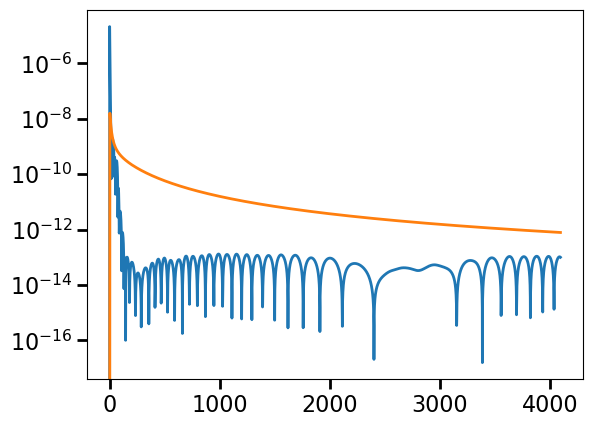

In [51]:
plt.figure()

plt.plot(np.abs(cell_glass_mock[9]))
plt.plot(np.abs(cell_glass_mock_ia_bias[9]))

plt.yscale('log')
plt.show()